In [32]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [33]:
housing = fetch_california_housing()

data = pd.DataFrame(housing.data,columns=housing.feature_names)
data["Price"]=housing.target

X = data[['AveRooms']].values
y = data['Price'].values


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2,
        random_state=42 
)
                                            

In [35]:
scaler=StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
w=0
b=0

learing_rate = 0.01
epochs = 1000
cost_history = []
n = len(X_train_scaled)

for i in range (epochs):
    y_pred = w * X_train_scaled.flatten()+b
    cost = (1/(2*n)) * np.sum((y_pred - y_train)**2)
    cost_history.append(cost)
    dw = (1/n) * np.sum((y_pred - y_train) * X_train_scaled.flatten())
    db = (1/n) * np.sum(y_pred - y_train)
    w = w - learing_rate*dw
    b = b - learing_rate*db

    if i % 100 == 0:
        print(f"Epoch {i}, Cost = {cost:.4f}")
y_pred_gd = w * X_test_scaled.flatten() + b

Epoch 0, Cost = 2.8149
Epoch 100, Cost = 0.9414
Epoch 200, Cost = 0.6904
Epoch 300, Cost = 0.6568
Epoch 400, Cost = 0.6523
Epoch 500, Cost = 0.6517
Epoch 600, Cost = 0.6516
Epoch 700, Cost = 0.6516
Epoch 800, Cost = 0.6516
Epoch 900, Cost = 0.6516


In [51]:
print(" Gradient Decent ")
print("---------------------")
print("Weight: " , w)
print("Bias: " , b)
print("MSE: " , mean_squared_error(y_test, y_pred_gd))
print("R2 Score: ", r2_score(y_test, y_pred_gd))

 Gradient Decent 
---------------------
Weight:  0.18323090648660517
Bias:  2.0718574888450205
MSE:  1.292327655590046
R2 Score:  0.013798228607320828


In [52]:
X_train_ne = np.c_[np.ones((len(X_train),1)),X_train]
X_test_ne = np.c_[np.ones((len(X_test),1)),X_test]

theta = np.linalg.inv(X_train_ne.T @ X_train_ne)@ X_train_ne.T @ y_train
y_pred_ne = X_test_ne @ theta

In [54]:
print("\n Normal Equation")
print("------------------------")
print("Intercept : ",theta[0])
print("Slop : ",theta[1])
print("MSE : ",mean_squared_error(y_test, y_pred_ne))
print("R2 Score : ",r2_score(y_test, y_pred_ne))


 Normal Equation
------------------------
Intercept :  1.6547622685968417
Slop :  0.07675558963126736
MSE :  1.2923314440807299
R2 Score :  0.013795337532284901


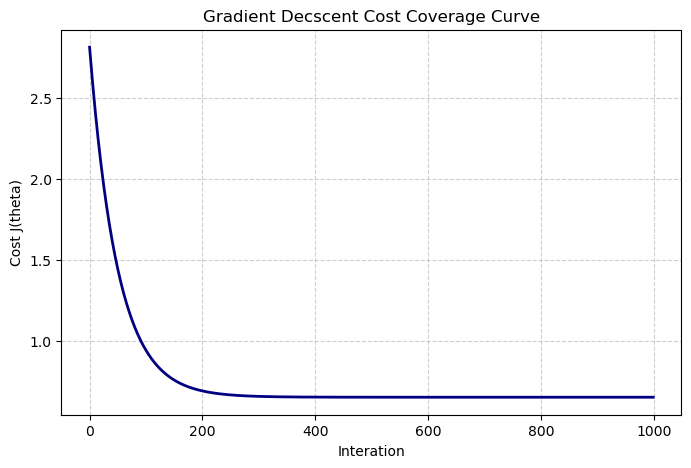

In [55]:
plt.figure(figsize=(8,5))
plt.plot(cost_history, color='navy', linewidth=2)
plt.title("Gradient Decscent Cost Coverage Curve" )
plt.xlabel('Interation')
plt.ylabel('Cost J(theta)')
plt.grid(True ,linestyle='--',alpha=0.6)

plt.show()
         